# Setup

In colab:
1. Go to "Runtime" -> "Change runtime type" -> Select "T4 GPU"
2. Install TerraTorch

In [ ]:
# Install required packages in Colab
!pip install git+https://github.com/IBM/terratorch.git
!pip install rioxarray matplotlib
!wget https://raw.githubusercontent.com/IBM/terramind/refs/heads/main/notebooks/plotting_utils.py

In [1]:
import os
import torch
import rioxarray as rxr
import matplotlib.pyplot as plt
from terratorch.registry import FULL_MODEL_REGISTRY
import sys
sys.path.append('../')
from src.utils import plot_s2, plot_modality

# Select device
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

/home/egm/Data/anaconda3/envs/terramind/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [8]:
# Build model that generates S-2 L2A (via tokenizer), S-1 GRD, S-1 RTC, DEM, LULC, and NDVI based on raw S-2 L2A input.
# Please note that each output modality requires its own tokenizer which increases the memory requirements
model = FULL_MODEL_REGISTRY.build(
    'terramind_v1_base_generate',
    modalities=['S2L2A'],  # Define the input
    output_modalities=["S2L1C"],  # Define the output from S2L2A, S1GRD, S1RTC, DEM, LULC, and NDVI
    pretrained=True,
    standardize=True,  # If standardize=True, you don't need to do the standardization yourself.
    # offset={'S2L2A': 1000}  # Optional offset in your data. The offset is also applied to the generation. 
)

_ = model.to(device)

# If you need the standardization values, see
from terratorch.models.backbones.terramind.model.terramind_register import v1_pretraining_mean, v1_pretraining_std

[DEBUG] Tokenizer keys loaded: dict_keys(['tok_sen2l2a@224'])


In [4]:
# Save the model
torch.save(model, '../models/terramind_v1_base_generate.pth')

In [9]:
# if os.path.exists('../examples'):
#   # Load local S-2 L2A example paths
#   examples = [
#       '../examples/S2L2A/38D_378R_2_3.tif',
#       '../examples/S2L2A/282D_485L_3_3.tif',
#       '../examples/S2L2A/433D_629L_3_1.tif',
#       '../examples/S2L2A/637U_59R_1_3.tif',
#       '../examples/S2L2A/609U_541L_3_0.tif',
#   ]
# else:
#   # Download examples to Colab
#   !wget -q https://raw.githubusercontent.com/IBM/terramind/refs/heads/main/examples/S2L2A/38D_378R_2_3.tif
#   !wget -q https://raw.githubusercontent.com/IBM/terramind/refs/heads/main/examples/S2L2A/282D_485L_3_3.tif
#   !wget -q https://raw.githubusercontent.com/IBM/terramind/refs/heads/main/examples/S2L2A/433D_629L_3_1.tif
#   !wget -q https://raw.githubusercontent.com/IBM/terramind/refs/heads/main/examples/S2L2A/637U_59R_1_3.tif
#   !wget -q https://raw.githubusercontent.com/IBM/terramind/refs/heads/main/examples/S2L2A/541L_3_0.tif
examples = [
    '38D_378R_2_3.tif',
    '282D_485L_3_3.tif',
    '433D_629L_3_1.tif',
    '637U_59R_1_3.tif',
    '609U_541L_3_0.tif',
]

In [10]:
example_id = 1  # Select id between 0 and 4
# Load an S-2 L2A example
data = rxr.open_rasterio(examples[example_id])
# Convert to shape [B, C, 224, 224]
data = torch.Tensor(data.values, device='cpu').unsqueeze(0)

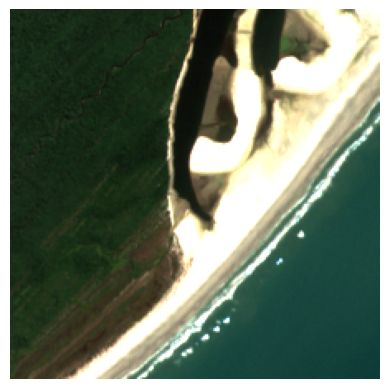

In [11]:
# Visualize S-2 L2A input as RGB
plot_s2(data)

In [12]:
# Run model with diffusion steps
input = data.to(device)
with torch.no_grad():
  generated = model(input, verbose=True, timesteps=10)

100%|██████████| 10/10 [00:02<00:00,  3.45it/s]


In [15]:
def analyze_image(example_id=None):
    """Comprehensive image analysis"""
    
    if example_id is not None:
        file_path = examples[example_id]
    
    print("="*50)
    print(f"ANALYZING: {file_path}")
    print("="*50)
    
    # Load with rioxarray
    data_xr = rxr.open_rasterio(file_path)
    
    # Basic info
    print("BASIC INFORMATION:")
    print(f"  File format: {file_path.split('.')[-1].upper()}")
    print(f"  Shape (bands, height, width): {data_xr.shape}")
    print(f"  Data type: {data_xr.dtype}")
    print(f"  Size: {data_xr.nbytes / 1024**2:.2f} MB")
    
    # Spatial info
    print("\nSPATIAL INFORMATION:")
    print(f"  CRS: {data_xr.rio.crs}")
    print(f"  Bounds: {data_xr.rio.bounds()}")
    print(f"  Resolution (x, y): {data_xr.rio.resolution()}")
    print(f"  Transform: {data_xr.rio.transform()}")
    
    # Data characteristics
    print("\nDATA CHARACTERISTICS:")
    print(f"  NoData value: {data_xr.rio.nodata}")
    print(f"  Number of bands: {data_xr.rio.count}")
    print(f"  Band names/numbers: {list(data_xr.band.values)}")
    
    # Value statistics
    print(f"\nVALUE STATISTICS:")
    print(f"  Overall min: {float(data_xr.min().values):.4f}")
    print(f"  Overall max: {float(data_xr.max().values):.4f}")
    print(f"  Overall mean: {float(data_xr.mean().values):.4f}")
    print(f"  Overall std: {float(data_xr.std().values):.4f}")
    
    # Check for special values
    nan_count = int(torch.isnan(torch.tensor(data_xr.values)).sum())
    inf_count = int(torch.isinf(torch.tensor(data_xr.values)).sum())
    print(f"  NaN values: {nan_count}")
    print(f"  Infinite values: {inf_count}")
    
    # Per-band analysis
    print(f"\nPER-BAND ANALYSIS:")
    for i, band in enumerate(data_xr.band.values):
        band_data = data_xr.sel(band=band)
        print(f"  Band {i+1:2d}: min={float(band_data.min().values):8.2f}, "
              f"max={float(band_data.max().values):8.2f}, "
              f"mean={float(band_data.mean().values):8.2f}, "
              f"std={float(band_data.std().values):8.2f}")
    
    # Convert to tensor and check divisibility
    data_tensor = torch.Tensor(data_xr.values).unsqueeze(0)
    B, C, H, W = data_tensor.shape
    print(f"\nTENSOR INFORMATION:")
    print(f"  Tensor shape: {data_tensor.shape}")
    print(f"  Divisible by 16: H={H%16==0}, W={W%16==0}")
    if H % 16 != 0 or W % 16 != 0:
        new_H = (H // 16) * 16
        new_W = (W // 16) * 16
        print(f"  Suggested crop size: {new_H}x{new_W} (loses {H-new_H}x{W-new_W} pixels)")
    
    return data_xr, data_tensor

# Use the function
data_xr, data_tensor = analyze_image(example_id=0)

ANALYZING: 38D_378R_2_3.tif
BASIC INFORMATION:
  File format: TIF
  Shape (bands, height, width): (12, 224, 224)
  Data type: int16
  Size: 1.15 MB

SPATIAL INFORMATION:
  CRS: EPSG:32736
  Bounds: (617301.8198784497, 9622858.22745184, 619541.8198784497, 9625098.22745184)
  Resolution (x, y): (10.0, -10.0)
  Transform: | 10.00, 0.00, 617301.82|
| 0.00,-10.00, 9625098.23|
| 0.00, 0.00, 1.00|

DATA CHARACTERISTICS:
  NoData value: None
  Number of bands: 12
  Band names/numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

VALUE STATISTICS:
  Overall min: 257.0000
  Overall max: 5374.0000
  Overall mean: 2189.6201
  Overall std: 975.1010
  NaN values: 0
  Infinite values: 0

PER-BAND ANALYSIS:
  Band  1: min=  418.00, max= 1298.00, mean=  686.86, std=  154.04
  Band  2: min=  257.00, max= 2166.00, mean=  824.78, std=  251.41
  Band  3: min=  478.00, max= 2670.00, mean= 1163.15, std=  313.92
  Band  4: min=  407.00, max= 3372.00, mean= 1589.02, std=  431.67
  Band  5: min=  946.00, max= 3668.

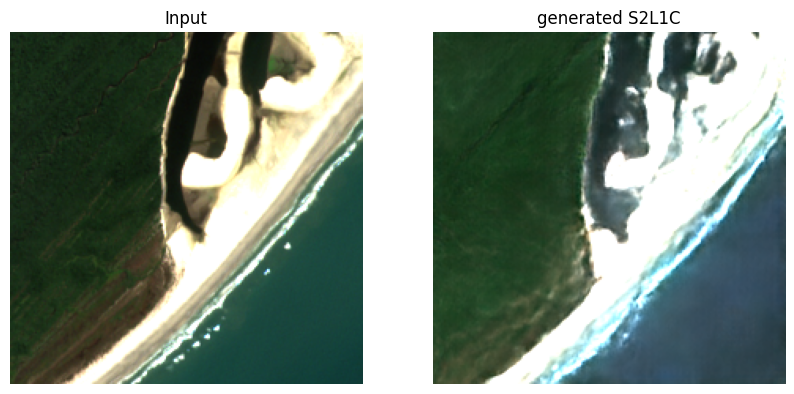

In [13]:
# Plot generations
n_plots = len(generated) + 1
fig, ax = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

plot_s2(input, ax=ax[0])
ax[0].set_title('Input')

for i, (mod, value) in enumerate(generated.items()):
    plot_modality(mod, value, ax=ax[i + 1])

    ax[i+1].set_title('generated ' + mod)
    
plt.show()

In [15]:

# DEBUG: Print the number of bands in S2L1C output
print("="*60)
print("S2L1C OUTPUT ANALYSIS")
print("="*60)

s2l1c_output = generated['S2L1C']
print(f"S2L1C output shape: {s2l1c_output.shape}")
print(f"S2L1C output dimensions: {s2l1c_output.dim()}")

# Extract number of bands (channels)
if s2l1c_output.dim() == 4:  # [batch, channels, height, width]
    num_bands = s2l1c_output.shape[1]
elif s2l1c_output.dim() == 3:  # [channels, height, width]
    num_bands = s2l1c_output.shape[0]
else:
    num_bands = "Unknown - unexpected shape"

print(f"Number of bands in S2L1C output: {num_bands}")
print(f"Expected for S2L1C: 13 bands")

if isinstance(num_bands, int):
    if num_bands == 13:
        print("✅ Correct number of bands!")
    elif num_bands == 12:
        print("❌ Missing 1 band - model outputs 12 instead of 13")
    else:
        print(f"❌ Unexpected number of bands: {num_bands}")

# Print band-by-band statistics
if isinstance(num_bands, int) and s2l1c_output.dim() >= 3:
    print(f"\nPER-BAND STATISTICS:")
    for i in range(num_bands):
        if s2l1c_output.dim() == 4:
            band_data = s2l1c_output[0, i, :, :]  # [batch, channel, h, w]
        else:
            band_data = s2l1c_output[i, :, :]     # [channel, h, w]
        
        print(f"  Band {i+1:2d}: min={band_data.min().item():8.2f}, "
              f"max={band_data.max().item():8.2f}, "
              f"mean={band_data.mean().item():8.2f}, "
              f"std={band_data.std().item():8.2f}")

print("="*60)

S2L1C OUTPUT ANALYSIS
S2L1C output shape: torch.Size([1, 12, 224, 224])
S2L1C output dimensions: 4
Number of bands in S2L1C output: 12
Expected for S2L1C: 13 bands
❌ Missing 1 band - model outputs 12 instead of 13

PER-BAND STATISTICS:
  Band  1: min=   31.89, max= 3422.88, mean=  935.38, std=  895.76
  Band  2: min=   96.21, max= 3644.42, mean= 1075.87, std= 1058.37
  Band  3: min=  215.90, max= 3757.17, mean= 1174.66, std= 1054.16
  Band  4: min=  -36.92, max= 3988.05, mean=  987.02, std= 1119.42
  Band  5: min=  190.16, max= 4284.42, mean= 1233.88, std= 1095.10
  Band  6: min=  890.05, max= 4669.90, mean= 2185.16, std=  953.14
  Band  7: min= 1166.75, max= 4807.27, mean= 2589.02, std=  991.24
  Band  8: min= 1211.32, max= 4955.15, mean= 2564.71, std=  980.20
  Band  9: min= 1378.39, max= 4886.05, mean= 2700.35, std= 1003.63
  Band 10: min= 1365.61, max= 4922.68, mean= 2618.91, std=  916.74
  Band 11: min=  990.62, max= 3859.15, mean= 1616.80, std=  799.78
  Band 12: min=  523.34, ma

In [ ]:
import os
import torch
import rioxarray as rxr
import matplotlib.pyplot as plt
from terratorch.registry import FULL_MODEL_REGISTRY
import sys
sys.path.append('../')
from src.utils import plot_s2, plot_modality

# Select device
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

In [ ]:
# Build model that generates S-2 L2A (via tokenizer), S-1 GRD, S-1 RTC, DEM, LULC, and NDVI based on raw S-2 L2A input.
# Please note that each output modality requires its own tokenizer which increases the memory requirements
model = FULL_MODEL_REGISTRY.build(
    'terramind_v1_base_generate',
    modalities=['coords'],  # Define the input
    output_modalities=['S1GRD', 'DEM', 'LULC'],  # Define the output from S2L2A, S1GRD, S1RTC, DEM, LULC, and NDVI
    pretrained=True,
    standardize=True,  # If standardize=True, you don't need to do the standardization yourself.
    # offset={'S2L2A': 1000}  # Optional offset in your data. The offset is also applied to the generation. 
)

_ = model.to(device)

# If you need the standardization values, see
from terratorch.models.backbones.terramind.model.terramind_register import v1_pretraining_mean, v1_pretraining_std

In [ ]:
# Then you need to provide coordinate input instead of S2L2A image:
# Example coordinates (lat, lon) - you'd need real coordinates for your test area
coords_input = torch.tensor([[45.0, 2.0]], device=device)  # [batch, 2] format
print(f"Coordinate input shape: {coords_input.shape}")

# Run model with coordinate input
with torch.no_grad():
    generated = model(coords_input, verbose=True, timesteps=10)

In [ ]:
# Fix the plotting cell to show coordinate input correctly:
n_plots = len(generated) + 1
fig, ax = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

# Show coordinate input instead of S2 image
ax[0].text(0.5, 0.5, f'Coordinate Input:\nLat: {coords_input[0][0].item():.1f}°\nLon: {coords_input[0][1].item():.1f}°', 
           ha='center', va='center', fontsize=16, 
           bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)
ax[0].set_title('Input (Coordinates)')
ax[0].axis('off')

# Plot the generated modalities
for i, (mod, value) in enumerate(generated.items()):
    plot_modality(mod, value, ax=ax[i + 1])
    ax[i+1].set_title(f'Generated {mod}')
    
plt.tight_layout()
plt.show()

In [2]:
import os
import torch
import rioxarray as rxr
import matplotlib.pyplot as plt
from terratorch.registry import FULL_MODEL_REGISTRY
import sys
sys.path.append('../')
from src.utils import plot_s2, plot_modality

# Select device
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

In [3]:
# Build model that generates S-2 L2A (via tokenizer), S-1 GRD, S-1 RTC, DEM, LULC, and NDVI based on raw S-2 L2A input.
# Please note that each output modality requires its own tokenizer which increases the memory requirements
model = FULL_MODEL_REGISTRY.build(
    'terramind_v1_base_generate',
    modalities=['S2L2A'],  # Define the input
    output_modalities=['coords'],  # Define the output from S2L2A, S1GRD, S1RTC, DEM, LULC, and NDVI
    pretrained=True,
    standardize=True,  # If standardize=True, you don't need to do the standardization yourself.
    # offset={'S2L2A': 1000}  # Optional offset in your data. The offset is also applied to the generation. 
)

_ = model.to(device)

# If you need the standardization values, see
from terratorch.models.backbones.terramind.model.terramind_register import v1_pretraining_mean, v1_pretraining_std

🔍 DEBUG: terramind_v1_coords_tokenizer called with:
  pretrained=True
  tokenizer_file=None
  args=()
  kwargs={}
🔍 DEBUG: Checking download condition:
  pretrained=True
  tokenizer_file is None: True
  Combined condition: True
🔍 DEBUG: Attempting to download tokenizer...
  repo_id: ibm-esa-geospatial/TerraMind-1.0-Tokenizer-Coords
  filename: config.json


config.json: 0.00B [00:00, ?B/s]

✅ DEBUG: Successfully downloaded tokenizer to: /home/egm/.cache/huggingface/hub/models--ibm-esa-geospatial--TerraMind-1.0-Tokenizer-Coords/snapshots/b6664f494c2d79f9205525d2f3445413813214de/config.json
🔍 DEBUG: Creating CoordsTokenizer with tokenizer_file=/home/egm/.cache/huggingface/hub/models--ibm-esa-geospatial--TerraMind-1.0-Tokenizer-Coords/snapshots/b6664f494c2d79f9205525d2f3445413813214de/config.json
✅ DEBUG: Successfully created CoordsTokenizer
🔍 DEBUG: Tokenizer vocabulary size: 2169
🔍 DEBUG: First 10 tokens: ['lon=76.00', 'lat=-72.50', 'lon=-161.50', 'lon=145.25', 'lon=1.50', 'lat=-60.25', 'lon=-36.75', 'lon=-117.00', 'lon=103.25', 'lat=-15.50']
[DEBUG] Tokenizer keys loaded: dict_keys(['coords'])
[DEBUG] Coords tokenizer class: CoordsTokenizer
[DEBUG] Coords tokenizer object: Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[{"id":0, "content":"[PAD]", "single_word":False, "lstrip":False, "rstrip":False, ...}, {"id":1, "content":"[UNK]", "single_word":Fal

In [4]:
examples = [
    '38D_378R_2_3.tif',
    '282D_485L_3_3.tif',
    '433D_629L_3_1.tif',
    '637U_59R_1_3.tif',
    '609U_541L_3_0.tif',
]

In [5]:
example_id = 1  # Select id between 0 and 4
# Load an S-2 L2A example
data = rxr.open_rasterio(examples[example_id])
# Convert to shape [B, C, 224, 224]
data = torch.Tensor(data.values, device='cpu').unsqueeze(0)

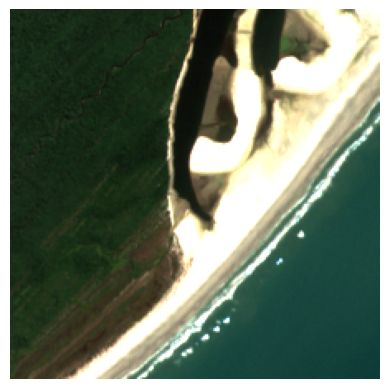

In [6]:
# Visualize S-2 L2A input as RGB
plot_s2(data)

In [7]:
# Run model with diffusion steps
input = data.to(device)
with torch.no_grad():
  generated = model(input, verbose=True, timesteps=10)

[DEBUG] Example 0: Token sequence: [4465, 5454, 3]
[DEBUG] Example 0: Decoded text: 'lat=-24.75 lon=-47.75 [EOS]'
[DEBUG] Failed to parse coords from text: 'lat=-24.75 lon=-47.75 [EOS]' (Error: too many values to unpack (expected 2))


In [9]:
model.tokenizer["coords"].text_tokenizer

The OrderedVocab you are attempting to save contains holes for indices [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211,

Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[{"id":0, "content":"[PAD]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":1, "content":"[UNK]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":2, "content":"[SOS]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":3, "content":"[EOS]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":4, "content":"[S_0]", "single_word":True, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":5, "content":"[S_1]", "single_word":True, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":6, "content":"[S_2]", "single_word":True, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":4204, "content":"lat=-90.00", "single_word":True, "lstrip":False, "rstrip":False, "normalized":False,

 2510, 2511, 2512, 2513, 2514, 2515, 2516, 2517, 2518, 2519, 2520, 2521, 2522, 2523, 2524, 2525, 2526, 2527, 2528, 2529, 2530, 2531, 2532, 2533, 2534, 2535, 2536, 2537, 2538, 2539, 2540, 2541, 2542, 2543, 2544, 2545, 2546, 2547, 2548, 2549, 2550, 2551, 2552, 2553, 2554, 2555, 2556, 2557, 2558, 2559, 2560, 2561, 2562, 2563, 2564, 2565, 2566, 2567, 2568, 2569, 2570, 2571, 2572, 2573, 2574, 2575, 2576, 2577, 2578, 2579, 2580, 2581, 2582, 2583, 2584, 2585, 2586, 2587, 2588, 2589, 2590, 2591, 2592, 2593, 2594, 2595, 2596, 2597, 2598, 2599, 2600, 2601, 2602, 2603, 2604, 2605, 2606, 2607, 2608, 2609, 2610, 2611, 2612, 2613, 2614, 2615, 2616, 2617, 2618, 2619, 2620, 2621, 2622, 2623, 2624, 2625, 2626, 2627, 2628, 2629, 2630, 2631, 2632, 2633, 2634, 2635, 2636, 2637, 2638, 2639, 2640, 2641, 2642, 2643, 2644, 2645, 2646, 2647, 2648, 2649, 2650, 2651, 2652, 2653, 2654, 2655, 2656, 2657, 2658, 2659, 2660, 2661, 2662, 2663, 2664, 2665, 2666, 2667, 2668, 2669, 2670, 2671, 2672, 2673, 2674, 2675, 267

In [10]:
print(model.tokenizer["coords"].text_tokenizer.id_to_token(4475))
print(model.tokenizer["coords"].text_tokenizer.id_to_token(5818))

lat=-22.25
lon=43.25


In [11]:
vocab = model.tokenizer["coords"].text_tokenizer.get_vocab()
sorted_vocab = sorted(vocab.items(), key=lambda x: x[1])  # sort by token ID
for token, idx in sorted_vocab:
    print(f"{idx}: {token}")


0: [PAD]
1: [UNK]
2: [SOS]
3: [EOS]
4: [S_0]
5: [S_1]
6: [S_2]
4204: lat=-90.00
4205: lat=-89.75
4206: lat=-89.50
4207: lat=-89.25
4208: lat=-89.00
4209: lat=-88.75
4210: lat=-88.50
4211: lat=-88.25
4212: lat=-88.00
4213: lat=-87.75
4214: lat=-87.50
4215: lat=-87.25
4216: lat=-87.00
4217: lat=-86.75
4218: lat=-86.50
4219: lat=-86.25
4220: lat=-86.00
4221: lat=-85.75
4222: lat=-85.50
4223: lat=-85.25
4224: lat=-85.00
4225: lat=-84.75
4226: lat=-84.50
4227: lat=-84.25
4228: lat=-84.00
4229: lat=-83.75
4230: lat=-83.50
4231: lat=-83.25
4232: lat=-83.00
4233: lat=-82.75
4234: lat=-82.50
4235: lat=-82.25
4236: lat=-82.00
4237: lat=-81.75
4238: lat=-81.50
4239: lat=-81.25
4240: lat=-81.00
4241: lat=-80.75
4242: lat=-80.50
4243: lat=-80.25
4244: lat=-80.00
4245: lat=-79.75
4246: lat=-79.50
4247: lat=-79.25
4248: lat=-79.00
4249: lat=-78.75
4250: lat=-78.50
4251: lat=-78.25
4252: lat=-78.00
4253: lat=-77.75
4254: lat=-77.50
4255: lat=-77.25
4256: lat=-77.00
4257: lat=-76.75
4258: lat=-76.50
42

In [12]:
# Check what tokenizer file should be loaded
print("Coordinate tokenizer configuration:")
print(f"Model has coords tokenizer: {'coords' in model.tokenizer}")
if 'coords' in model.tokenizer:
    coords_tok = model.tokenizer['coords']
    print(f"Tokenizer type: {type(coords_tok)}")
    print(f"Text tokenizer type: {type(coords_tok.text_tokenizer)}")
    
    # Check vocabulary size
    vocab = coords_tok.text_tokenizer.get_vocab()
    print(f"Vocabulary size: {len(vocab)}")
    print("Vocabulary contents:")
    for token, idx in sorted(vocab.items(), key=lambda x: x[1])[:20]:  # First 20 tokens
        print(f"  {idx}: '{token}'")

Coordinate tokenizer configuration:
Model has coords tokenizer: True
Tokenizer type: <class 'terratorch.models.backbones.terramind.tokenizer.text.text_tokenizer.CoordsTokenizer'>
Text tokenizer type: <class 'tokenizers.Tokenizer'>
Vocabulary size: 2169
Vocabulary contents:
  0: '[PAD]'
  1: '[UNK]'
  2: '[SOS]'
  3: '[EOS]'
  4: '[S_0]'
  5: '[S_1]'
  6: '[S_2]'
  4204: 'lat=-90.00'
  4205: 'lat=-89.75'
  4206: 'lat=-89.50'
  4207: 'lat=-89.25'
  4208: 'lat=-89.00'
  4209: 'lat=-88.75'
  4210: 'lat=-88.50'
  4211: 'lat=-88.25'
  4212: 'lat=-88.00'
  4213: 'lat=-87.75'
  4214: 'lat=-87.50'
  4215: 'lat=-87.25'
  4216: 'lat=-87.00'


CHANGED : /home/egm/Data/anaconda3/envs/terramind/lib/python3.10/site-packages/terratorch/models/backbones/terramind/tokenizer/tokenizer_register.py line 461-465!!

In [13]:
# Check what's available in the Hugging Face repositories
from huggingface_hub import list_repo_files, hf_hub_download

# Check the v1 coordinate tokenizer repo
print("=== Checking TerraMind v1.0 Coords Tokenizer ===")
try:
    files = list_repo_files("ibm-esa-geospatial/TerraMind-1.0-Tokenizer-Coords")
    print("Files available:", files)
except Exception as e:
    print(f"❌ TerraMind-1.0-Tokenizer-Coords not accessible: {e}")

# Check the v0.1 text tokenizer repo  
print("\n=== Checking TerraMind v0.1 Text Tokenizer ===")
try:
    files = list_repo_files("FAST-EO/TerraMind-v0.1-Tokenizer-Text")
    print("Files available:", files)
except Exception as e:
    print(f"❌ TerraMind-v0.1-Tokenizer-Text not accessible: {e}")

=== Checking TerraMind v1.0 Coords Tokenizer ===
Files available: ['.gitattributes', 'README.md', 'config.json']

=== Checking TerraMind v0.1 Text Tokenizer ===
Files available: ['.gitattributes', 'README.md', 'config.json']


In [ ]:
# Find the terratorch installation directory
python -c "import terratorch; print(terratorch.__file__)"

# Then search for tokenizer file references
cd /home/egm/Data/anaconda3/envs/terramind/lib/python3.10/site-packages/terratorch/
grep -r "tokenizer.*file" . --include="*.py"
grep -r "coords.*tokenizer" . --include="*.py"
grep -r "\.json" . --include="*.py" | grep -i tokenizer

SyntaxError: invalid syntax (1489063842.py, line 2)

In [ ]:
/home/egm/Data/anaconda3/envs/terramind/lib/python3.10/site-packages/terratorch/models/backbones/terramind/model/terramind.py

/home/egm/Data/anaconda3/envs/terramind/lib/python3.10/site-packages/terratorch/models/backbones/terramind/tokenizer/text/text_tokenizer.py

/home/egm/Data/anaconda3/envs/terramind/lib/python3.10/site-packages/terratorch/models/backbones/terramind/tokenizer/tokenizer_register.py

/home/egm/Data/anaconda3/envs/terramind/lib/python3.10/site-packages/terratorch/models/backbones/terramind/model/terramind_generation.py

https://huggingface.co/FAST-EO/TerraMind-v0.1-Tokenizer-Text/blob/main/config.json

SyntaxError: invalid syntax (1199416020.py, line 1)

In [14]:
# Add this cell to fix the coordinate plotting issue:
def plot_coordinates(coords_data, ax=None, **kwargs):
    """Plot coordinate data properly"""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    
    ax.axis('off')
    
    # Handle different coordinate formats
    if isinstance(coords_data, list) and len(coords_data) > 0:
        if isinstance(coords_data[0], (list, tuple)) and len(coords_data[0]) == 2:
            # Format: [[lat, lon]]
            lat, lon = coords_data[0]
        else:
            # Unexpected format
            lat, lon = float('nan'), float('nan')
    elif hasattr(coords_data, 'shape') and coords_data.shape[-1] == 2:
        # Tensor format
        coords_flat = coords_data.flatten()
        lat, lon = coords_flat[0].item(), coords_flat[1].item()
    else:
        lat, lon = float('nan'), float('nan')
    
    # Display the coordinates
    if not (pd.isna(lat) or pd.isna(lon)):
        text = f'Generated Coordinates:\nLatitude: {lat:.4f}°\nLongitude: {lon:.4f}°'
        
        # Validate coordinates
        if -90 <= lat <= 90 and -180 <= lon <= 180:
            color = 'green'
            status = '✅ Valid'
        else:
            color = 'orange'
            status = '⚠️ Out of range'
            
        text += f'\n\n{status}'
    else:
        text = 'Generated Coordinates:\n❌ NaN values\n(Tokenizer error)'
        color = 'red'
    
    ax.text(0.5, 0.5, text, ha='center', va='center', fontsize=14,
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", edgecolor=color))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    if ax is None:
        plt.show()

# Monkey patch the plot_modality function to handle coords properly
def fixed_plot_modality(modality, data, ax=None, **kwargs):
    """Fixed version that handles coordinates properly"""
    
    if 'coords' in modality.lower():
        plot_coordinates(data, ax=ax, **kwargs)
    elif 'caption' in modality.lower() or 'text' in modality.lower():
        # Handle text data
        if isinstance(data, list):
            text = str(data[0]) if data else "No text generated"
        else:
            text = str(data)
        
        if ax is None:
            fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        
        ax.axis('off')
        ax.text(0.5, 0.5, text, ha='center', va='center', fontsize=14,
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray"))
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    else:
        # Use the original plot_modality for other modalities
        from src.utils import plot_modality as original_plot_modality
        original_plot_modality(modality, data, ax=ax, **kwargs)

# Apply the fix
import src.utils.plottingutils as plotting_utils
plotting_utils.plot_modality = fixed_plot_modality

print("Applied coordinate plotting fix!")

Applied coordinate plotting fix!


/tmp/ipykernel_1806466/561860260.py:14: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Data/egm/anaconda3/envs/terramind/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


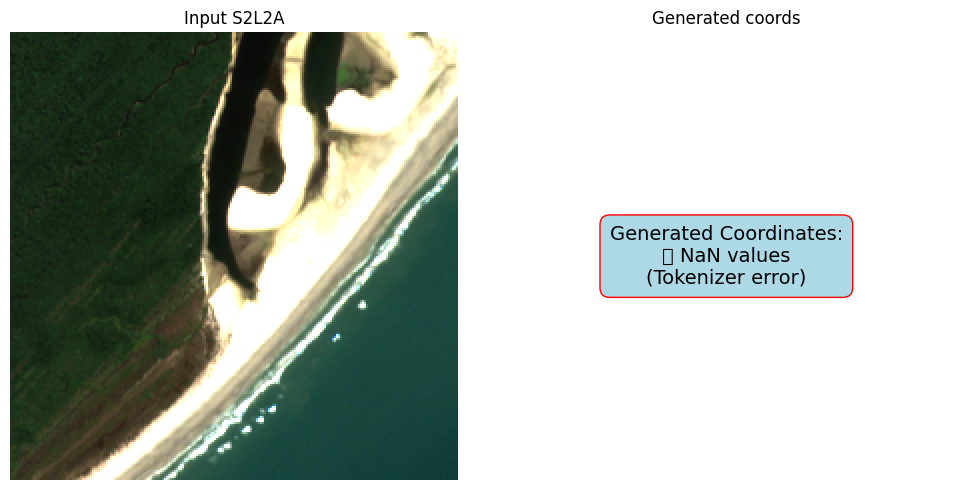


=== COORDINATE GENERATION DEBUG ===
Generated coordinates: [[nan, nan]]
Type: <class 'list'>
First coordinate pair: [nan, nan]
Values: lat=nan, lon=nan
❌ Generated NaN coordinates - confirms the tokenizer bug!


In [15]:
import pandas as pd

# Plot generations with fixed coordinate handling
n_plots = len(generated) + 1
fig, ax = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

plot_s2(input, ax=ax[0])
ax[0].set_title('Input S2L2A')

for i, (mod, value) in enumerate(generated.items()):
    fixed_plot_modality(mod, value, ax=ax[i + 1])
    ax[i+1].set_title(f'Generated {mod}')
    
plt.tight_layout()
plt.show()

# Also print the raw coordinate data for debugging
print("\n=== COORDINATE GENERATION DEBUG ===")
print(f"Generated coordinates: {generated['coords']}")
print(f"Type: {type(generated['coords'])}")
if isinstance(generated['coords'], list) and generated['coords']:
    print(f"First coordinate pair: {generated['coords'][0]}")
    print(f"Values: lat={generated['coords'][0][0]}, lon={generated['coords'][0][1]}")
    
    import pandas as pd
    if pd.isna(generated['coords'][0][0]) or pd.isna(generated['coords'][0][1]):
        print("❌ Generated NaN coordinates - confirms the tokenizer bug!")
    else:
        print("✅ Generated valid coordinates!")